# Exploratory Data Analysis

In [1]:
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns  

df = pd.read_csv('C:/Users/jhonn/Downloads/data_jobs.csv')

#Cleaning the date 
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

In [2]:
# Filter for US Data Analyst Jobs.
df_usa_da = df[(df['job_title_short']=='Data Analyst') & (df['job_location'] == 'United States')].copy()

In [9]:
df_usa_da.head()

,job_title_short,job_title,job_location,job_via,job_schedule_type,job_work_from_home,search_location,job_posted_date,job_no_degree_mention,job_health_insurance,job_country,salary_rate,salary_year_avg,salary_hour_avg,company_name,job_skills,job_type_skills
1078,Data Analyst,"Data Analyst, Education Policy Studies",United States,via LinkedIn,Full-time,False,"Illinois, United States",2023-07-07 13:06:26,False,False,United States,NaN,NaN,NaN,American Enterprise Institute,"[html, css, javascript, r, python, sql, tablea...","{'analyst_tools': ['tableau', 'power bi', 'out..."
4237,Data Analyst,Data Analytics,United States,via BeBee,Full-time,False,Sudan,2023-11-25 14:10:41,False,True,Sudan,NaN,NaN,NaN,Guidehouse,"[sql, python, r, tableau]","{'analyst_tools': ['tableau'], 'programming': ..."
5722,Data Analyst,Data Analyst,United States,via LinkedIn,Full-time,False,"Illinois, United States",2023-10-19 13:25:26,False,False,United States,NaN,NaN,NaN,Gibson Consulting,"[sql, python, c++, java, r, sas, sas, azure, a...","{'analyst_tools': ['sas', 'excel', 'powerpoint..."
18059,Data Analyst,Data Management Analyst - Avendra,United States,via Ai-Jobs.net,Full-time,False,"Texas, United States",2023-12-16 13:02:31,False,False,United States,year,54000.0,NaN,Aramark,"[sql, excel, ms access]","{'analyst_tools': ['excel', 'ms access'], 'pro..."
19941,Data Analyst,Session Lead (External Contractor) - Data Anal...,United States,via Ai-Jobs.net,Part-time,False,"Texas, United States",2023-07-25 13:04:46,True,False,United States,year,100500.0,NaN,"Udacity, Inc.","[python, sql, numpy, pandas, zoom, slack]","{'libraries': ['numpy', 'pandas'], 'programmin..."


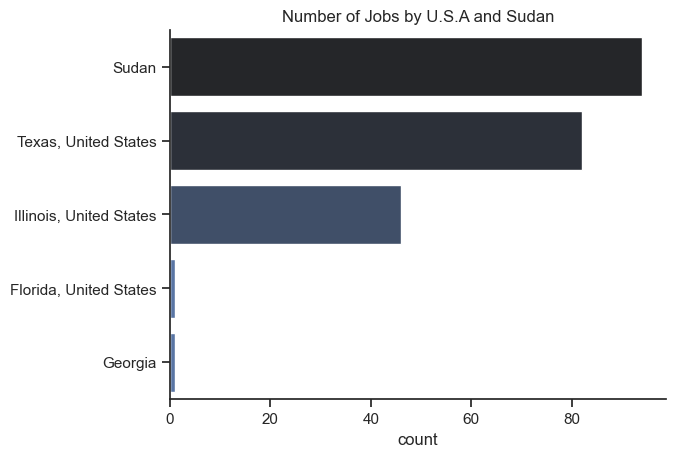

In [31]:
df_cities = df_usa_da['search_location'].value_counts().to_frame()

#Plotting
sns.set_theme(style = 'ticks')
sns.barplot(data = df_cities, x='count', y='search_location', hue = 'count', palette = 'dark:b_r', legend = False)
sns.despine()
plt.title('Number of Jobs by U.S.A and Sudan')
plt.ylabel("")
plt.show()



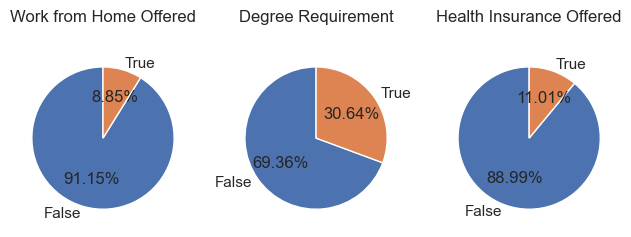

In [32]:
#Plotting pie chart
fig, ax = plt.subplots(1,3)

dict_column = {
    'job_work_from_home': 'Work from Home Offered',
    'job_no_degree_mention': 'Degree Requirement',
    'job_health_insurance': 'Health Insurance Offered'
}

for i, (column, title) in enumerate (dict_column.items()):
    ax[i].pie(df[column].value_counts(), startangle= 90, autopct='%1.2f%%', labels=['False', 'True'])
    ax[i].set_title(title, pad=20)


plt.tight_layout()

plt.show()

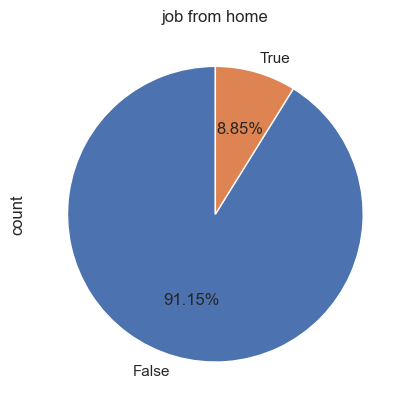

In [39]:
# Direct Pandas plotting
df['job_work_from_home'].value_counts().plot(kind='pie',autopct='%1.2f%%', startangle=90)
plt.title('job from home')
plt.show()

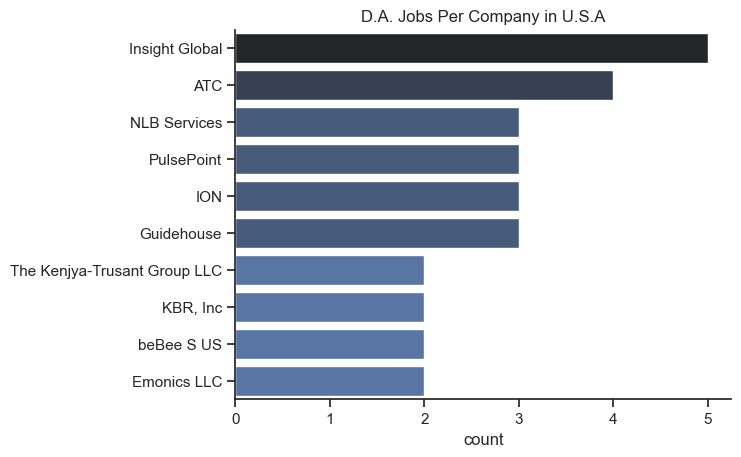

In [42]:
df_companies = df_usa_da['company_name'].value_counts().to_frame().head(10)

#Plotting
sns.set_theme(style = 'ticks')
sns.barplot(data = df_companies, x='count', y='company_name', hue = 'count', palette = 'dark:b_r', legend = False)
sns.despine()
plt.title('D.A. Jobs Per Company in U.S.A')
plt.ylabel("")
plt.show()
